# LSTM temporel (TensorFlow/Keras) — benchmark **LSTM · GRU · TCN · BiLSTM · TFT** — prévision **Heat Index** (NOAA GSOD, stations Maroc)

Copie de `temporal_training/lstm_nasa_power.ipynb` repointée sur le jeu
`data/cleandata_gsod_by_station`. Approche **séries temporelles par station** en
**TensorFlow/Keras** : on entraîne et compare cinq modèles temporels — **LSTM**,
**GRU**, **TCN**, **BiLSTM**, **TFT** — à partir des `INPUT_WINDOW` derniers jours
de variables météo, on prédit les `OUTPUT_WINDOW` prochains jours du **heat_index**.

> **Note** — `heat_index` figure à la fois dans les *features* et comme *cible* :
> c'est de la **prévision autorégressive**. La fenêtre d'entrée (passé) et la fenêtre
> de sortie (futur) sont **disjointes dans le temps**, donc utiliser le heat_index
> passé pour prédire le heat_index futur n'est pas une fuite de données.

Pipeline : chargement → nettoyage → features → heatmap de corrélation →
**split chronologique par station 70/15/15** → **normalisation Min-Max (fit train only)**
→ fenêtrage (par station) → modèles Keras → entraînement (`model.fit` + callbacks)
→ évaluation (RMSE/MAE/R²) → comparaison → visualisation → sauvegarde
(`.keras` + scalers).

## 0. Imports & configuration

In [21]:
import os, glob, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings; warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.1
GPU: []


In [22]:
# ── Configuration centrale du benchmark (source de vérité unique) ──
from dataclasses import dataclass, field, asdict
from typing import List

@dataclass
class Config:
    """Tous les hyperparamètres, chemins, features et cible du benchmark LSTM
    temporel (NOAA GSOD). Modifier ICI propage a tout le notebook."""
    # — Données / chemins —
    data_dir: str = ""            # résolu automatiquement ci-dessous
    art_dir:  str = "artifacts"
    # — Features & cible (sélectionnées PAR NOM, pas par slicing) —
    features: List[str] = field(default_factory=lambda: [
        "latitude", "longitude", "elevation",
        "tmax_c", "dewp_c", "humidity_pct",
        "wind_speed_ms", "press_hpa", "heat_index"
    ])
    target: str = "heat_index"
    # — Fenêtrage temporel —
    input_window:  int = 7        # jours passés fournis au modèle
    output_window: int = 7        # jours prédits
    # — Split chronologique par station (70 / 15 / 15) —
    train_ratio: float = 0.70
    val_ratio:   float = 0.15
    test_ratio:  float = 0.15
    # — Modèle —
    hidden:   int = 128
    n_layers: int = 3
    dropout:  float = 0.3
    # — Entraînement —
    batch_size: int = 256
    epochs:     int = 5
    lr:         float = 1e-3
    patience:   int = 8
    seed:       int = 42

    @property
    def n_features(self) -> int: return len(self.features)

# Résolution robuste du dossier de données (depuis trainig_station_noaa_DL/ ou racine du repo)
_CANDIDATES = ["../data/cleandata_gsod_by_station", "data/cleandata_gsod_by_station",
               os.path.expanduser("~/Documents/GitHub/PFE-Systeme-Alerte-Precoce-Maroc/data/cleandata_gsod_by_station")]
cfg = Config(data_dir=next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[0]))
assert abs(cfg.train_ratio + cfg.val_ratio + cfg.test_ratio - 1.0) < 1e-9, "les ratios doivent sommer à 1"

# Reproductibilité pilotée par la config
np.random.seed(cfg.seed); tf.random.set_seed(cfg.seed)

# ── Alias module-level (utilisés dans tout le notebook) ──
DATA_DIR = cfg.data_dir
ART_DIR  = Path(cfg.art_dir); ART_DIR.mkdir(exist_ok=True)
FEATURES = list(cfg.features)
TARGETS  = [cfg.target]          # cible unique -> liste à 1 élément (machinerie multi-cible réutilisée)
INPUT_WINDOW, OUTPUT_WINDOW = cfg.input_window, cfg.output_window
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
HIDDEN, N_LAYERS, DROPOUT = cfg.hidden, cfg.n_layers, cfg.dropout
BATCH_SIZE, EPOCHS, LR, PATIENCE = cfg.batch_size, cfg.epochs, cfg.lr, cfg.patience

print("Config centrale:\n" + json.dumps(asdict(cfg), indent=2, ensure_ascii=False))
print("DATA_DIR:", DATA_DIR)
print("FEATURES:", FEATURES)
print("TARGETS :", TARGETS)

Config centrale:
{
  "data_dir": "../data/cleandata_gsod_by_station",
  "art_dir": "artifacts",
  "features": [
    "latitude",
    "longitude",
    "elevation",
    "tmax_c",
    "dewp_c",
    "humidity_pct",
    "wind_speed_ms",
    "press_hpa",
    "heat_index"
  ],
  "target": "heat_index",
  "input_window": 7,
  "output_window": 7,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "hidden": 128,
  "n_layers": 3,
  "dropout": 0.3,
  "batch_size": 256,
  "epochs": 5,
  "lr": 0.001,
  "patience": 8,
  "seed": 42
}
DATA_DIR: ../data/cleandata_gsod_by_station
FEATURES: ['latitude', 'longitude', 'elevation', 'tmax_c', 'dewp_c', 'humidity_pct', 'wind_speed_ms', 'press_hpa', 'heat_index']
TARGETS : ['heat_index']


## 1. Load all stations

In [23]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
assert files, f"No CSVs in {DATA_DIR}"
frames = []
for f in files:
    df = pd.read_csv(f, parse_dates=["date"])
    df["station"] = Path(f).stem
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
print("stations:", data["station"].nunique(), "| rows:", len(data))
print("date range:", data["date"].min().date(), "->", data["date"].max().date())
data.head()

stations: 26 | rows: 324069
date range: 1990-01-01 -> 2025-08-24


,station_id,station_name,date,latitude,longitude,elevation,distance_to_ocean_km,tmax_c,tmin_c,tmean_c,dewp_c,humidity_pct,precip_mm,wind_speed_ms,press_hpa,heat_index,wind_chill,station
0,60155099999,Anfa,1990-01-01,33.556981,-7.660492,61.87,6.790714,19.000000,9.500000,13.777778,12.277778,90.665587,0.000,4.321330,1023.1,19.322935,7.229019,ANF_cleaned
1,60155099999,Anfa,1990-01-02,33.556981,-7.660492,61.87,6.790714,20.277778,10.000000,14.666667,12.277778,85.596693,0.000,4.424218,1021.7,20.596136,7.803991,ANF_cleaned
2,60155099999,Anfa,1990-01-03,33.556981,-7.660492,61.87,6.790714,14.888889,11.722222,13.111111,10.444444,83.868071,25.908,6.121884,1018.0,14.623222,11.722222,ANF_cleaned
3,60155099999,Anfa,1990-01-04,33.556981,-7.660492,61.87,6.790714,16.500000,8.500000,11.777778,9.277778,84.657247,10.922,2.932331,1025.2,16.416050,6.738982,ANF_cleaned
4,60155099999,Anfa,1990-01-05,33.556981,-7.660492,61.87,6.790714,16.722222,6.722222,12.000000,8.444444,78.862651,4.064,3.240997,1026.4,16.509191,4.401483,ANF_cleaned


## 2. Clean & feature engineering
Le jeu `cleandata_gsod_by_station` est déjà nettoyé (pas de valeur de remplissage
NASA, pas de padding de fin). On se contente donc de trier chronologiquement par
station et de retirer les lignes ayant un NaN dans une colonne utilisée.

In [24]:
data = data.sort_values(["station", "date"]).reset_index(drop=True)

# Drop rows with NaN in any used column
need = FEATURES + TARGETS
before = len(data); data = data.dropna(subset=need).reset_index(drop=True)
print(f"dropped {before-len(data)} NaN rows -> {len(data)} rows")
data[need].describe().round(2)

dropped 22740 NaN rows -> 301329 rows


,latitude,longitude,elevation,tmax_c,dewp_c,humidity_pct,wind_speed_ms,press_hpa,heat_index,heat_index
count,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00,301329.00
mean,32.24,-7.31,319.59,24.37,11.24,64.55,3.62,1010.16,25.30,25.30
std,3.03,3.28,369.89,6.39,5.98,18.66,2.24,25.59,8.01,8.01
min,23.70,-15.93,3.04,-0.39,-24.22,3.59,0.00,904.40,-1.94,-1.94
25%,30.94,-9.41,59.00,19.78,7.78,53.49,2.16,1012.90,19.66,19.66
50%,33.37,-6.75,199.03,23.89,11.94,69.10,3.09,1016.10,24.06,24.06
75%,34.79,-4.98,472.00,28.38,15.89,78.66,4.48,1019.60,30.32,30.32
max,35.59,-1.92,1515.00,50.22,25.78,100.00,22.74,1040.20,103.80,103.80


## 2bis. Matrice de corrélation (features & cible)
Heatmap de Pearson (seaborn) sur le jeu complet **après** nettoyage — pour repérer
la redondance et les liens avec la cible `heat_index` avant l'entraînement.

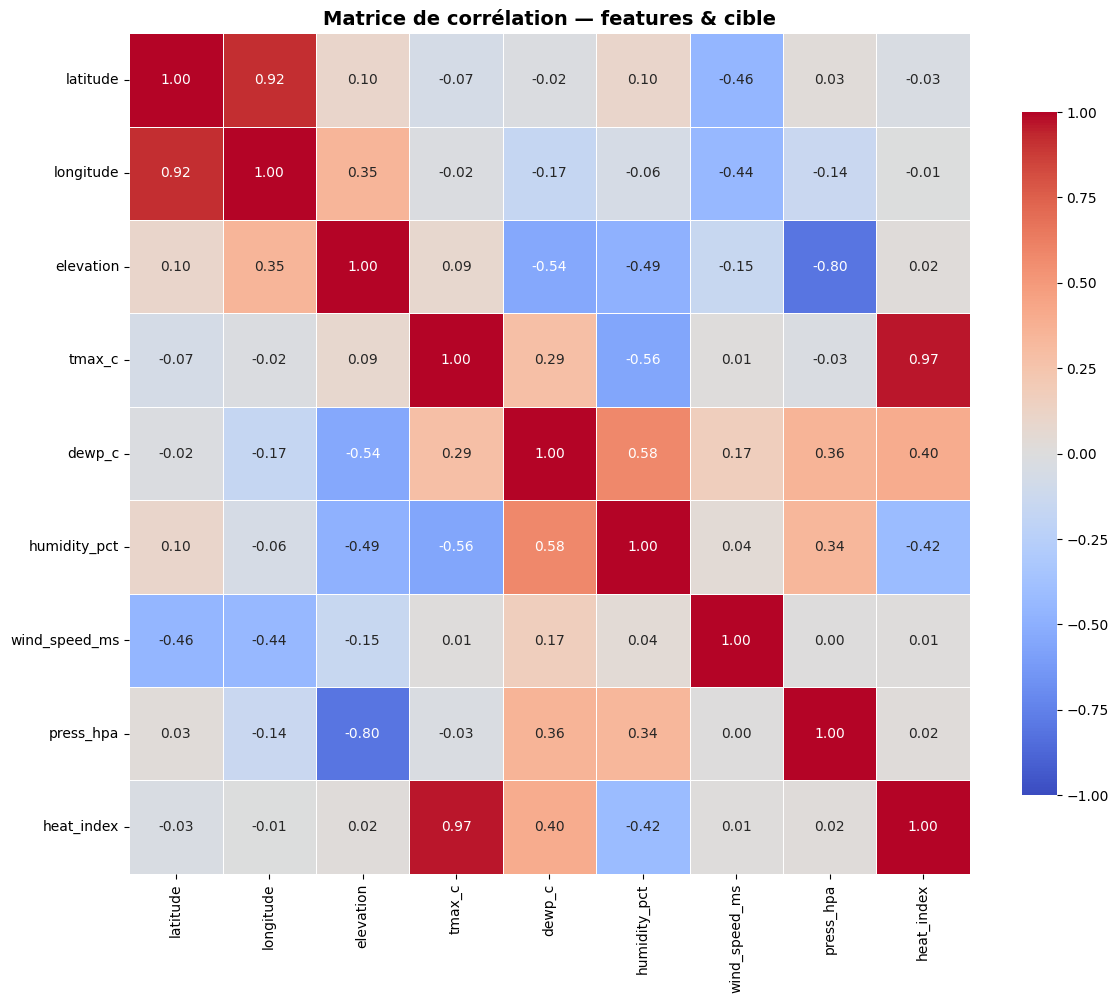

Paires |r| > 0.9 (redondance potentielle):
      heat_index ~ tmax_c         r=+0.966
       longitude ~ latitude       r=+0.918

Top |r| avec heat_index:
tmax_c          0.966
humidity_pct   -0.421
dewp_c          0.403
latitude       -0.033
press_hpa       0.022


In [25]:
# ── Heatmap de corrélation complète (features + cible) ──
corr_cols = list(dict.fromkeys(FEATURES + TARGETS))   # dé-doublonne (heat_index est feature ET cible)
corr = data[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation — features & cible", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Paires fortement colinéaires (|r| > 0.9, hors diagonale) -> redondance potentielle
keep = np.tril(np.ones_like(corr, dtype=bool), k=-1)
pairs = corr.where(keep).abs().stack().sort_values(ascending=False)
pairs = pairs[pairs > 0.9]
print("Paires |r| > 0.9 (redondance potentielle):")
for (a, b), _ in pairs.items():
    print(f"  {a:>14s} ~ {b:<14s} r={corr.loc[a, b]:+.3f}")

# Top corrélations (|r|) de la cible avec les features
for t in TARGETS:
    order = corr[t].drop(t).abs().sort_values(ascending=False).head(5).index
    print(f"\nTop |r| avec {t}:")
    print(corr.loc[order, t].round(3).to_string())

## 3. Split chronologique par station — 70 / 15 / 15
On découpe **chaque station** dans l'ordre temporel : 70 % d'abord (train),
puis 15 % (val), puis 15 % (test). Ce choix évite la fuite de données — pas de
mélange aléatoire, pas de chevauchement de stations entre les jeux, et chaque jeu
reste contigu dans le temps.

In [26]:
def split_station(g):
    g = g.sort_values("date")
    n = len(g)
    i_tr = int(n * TRAIN_RATIO)
    i_va = int(n * (TRAIN_RATIO + VAL_RATIO))
    return g.iloc[:i_tr], g.iloc[i_tr:i_va], g.iloc[i_va:]

parts = [split_station(g) for _, g in data.groupby("station")]
train_df = pd.concat([p[0] for p in parts], ignore_index=True)
val_df   = pd.concat([p[1] for p in parts], ignore_index=True)
test_df  = pd.concat([p[2] for p in parts], ignore_index=True)

tot = len(data)
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):7d} rows ({len(d)/tot*100:4.1f}%)  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}")

train:  210927 rows (70.0%)  1990-01-01 -> 2019-06-14
val  :   45199 rows (15.0%)  2012-06-06 -> 2022-07-19
test :   45203 rows (15.0%)  2017-03-28 -> 2025-08-24


## 4. Normalisation Min-Max (fit sur TRAIN uniquement)
`MinMaxScaler` sur les features et sur la cible, ajusté **seulement** sur le
train (pas de fuite). Le scaler des cibles est conservé pour l'inverse-transform.

In [27]:
scaler_X = MinMaxScaler().fit(train_df[FEATURES])
scaler_y = MinMaxScaler().fit(train_df[TARGETS])

def scale(df):
    df = df.copy()
    df[FEATURES] = scaler_X.transform(df[FEATURES])
    df[TARGETS]  = scaler_y.transform(df[TARGETS])
    return df

train_n, val_n, test_n = scale(train_df), scale(val_df), scale(test_df)
print("features range (train, post-scale):",
      float(train_n[FEATURES].min().min()), "->", float(train_n[FEATURES].max().max()))
print("targets data_min_ :", dict(zip(TARGETS, np.round(scaler_y.data_min_, 2))))
print("targets data_max_ :", dict(zip(TARGETS, np.round(scaler_y.data_max_, 2))))

features range (train, post-scale): 0.0 -> 1.0
targets data_min_ : {'heat_index': np.float64(-1.94)}
targets data_max_ : {'heat_index': np.float64(103.8)}


## 5. Windowing — per-station sliding sequences
Windows never cross a station boundary. X = INPUT_WINDOW days of features; y = next OUTPUT_WINDOW days of targets.

In [28]:
def make_sequences(df_norm):
    Xs, Ys = [], []
    win = INPUT_WINDOW + OUTPUT_WINDOW
    for _, g in df_norm.groupby("station"):
        g = g.sort_values("date")
        F = g[FEATURES].to_numpy(np.float32)
        T = g[TARGETS].to_numpy(np.float32)
        for i in range(len(g) - win + 1):
            Xs.append(F[i:i+INPUT_WINDOW])
            Ys.append(T[i+INPUT_WINDOW:i+win])
    if not Xs:
        return (np.empty((0,INPUT_WINDOW,len(FEATURES)),np.float32),
                np.empty((0,OUTPUT_WINDOW,len(TARGETS)),np.float32))
    return np.stack(Xs), np.stack(Ys)

X_tr, y_tr = make_sequences(train_n)
X_va, y_va = make_sequences(val_n)
X_te, y_te = make_sequences(test_n)
print("X_train:", X_tr.shape, "y_train:", y_tr.shape)
print("X_val  :", X_va.shape, "X_test:", X_te.shape)

X_train: (210615, 7, 9) y_train: (210615, 7, 1)
X_val  : (44887, 7, 9) X_test: (44891, 7, 9)


## 6. Modèles temporels Keras — LSTM · GRU · TCN · BiLSTM · TFT
Cinq architectures partageant la même interface `(INPUT_WINDOW, n_features) -> (OUTPUT_WINDOW, n_targets)`, donc directement comparables. RNN empilés (`N_LAYERS`) ; **BiLSTM** encode la fenêtre dans les deux sens ; **TCN** = convolutions 1D causales dilatées (non-récurrent) ; **TFT** = Temporal Fusion Transformer compact (GRN + encodeur LSTM + self-attention multi-tête).

In [29]:
def _grn(x, units, dropout=DROPOUT):
    """Gated Residual Network (Lim et al., 2021) — brique de base du TFT.
    Projection ELU -> gating GLU -> connexion résiduelle -> LayerNorm."""
    residual = x if x.shape[-1] == units else layers.Dense(units)(x)
    h = layers.Dense(units, activation="elu")(x)
    h = layers.Dense(units)(h)
    h = layers.Dropout(dropout)(h)
    gate = layers.Dense(units, activation="sigmoid")(h)   # GLU
    h = layers.Multiply()([h, gate])
    return layers.LayerNormalization()(layers.Add()([residual, h]))


def build_model(name):
    """Construit & compile un modèle Keras à partir de la config centrale."""
    nf, nt = len(FEATURES), len(TARGETS)
    inp = keras.Input(shape=(INPUT_WINDOW, nf))

    if name in ("LSTM", "GRU"):
        RNN = layers.LSTM if name == "LSTM" else layers.GRU
        x = inp
        for li in range(N_LAYERS):
            x = RNN(HIDDEN, return_sequences=(li < N_LAYERS - 1))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "BiLSTM":
        x = inp
        for li in range(N_LAYERS):                 # LSTM bidirectionnel (encodeur)
            x = layers.Bidirectional(
                layers.LSTM(HIDDEN, return_sequences=(li < N_LAYERS - 1)))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "TCN":
        x = inp
        for d in (1, 2, 4):                         # convolutions causales dilatées
            x = layers.Conv1D(HIDDEN, 3, padding="causal", dilation_rate=d,
                              activation="relu")(x)
            x = layers.Dropout(DROPOUT)(x)
        x = x[:, -1, :]                             # dernier pas de temps
    elif name == "TFT":
        # Temporal Fusion Transformer (version compacte) : embedding par variable
        # via GRN -> encodeur LSTM -> self-attention multi-tête interprétable -> GRN.
        u = HIDDEN
        x = layers.Dense(u)(inp)                    # embedding des variables
        x = _grn(x, u)                              # variable selection / processing
        x = layers.LSTM(u, return_sequences=True)(x)  # traitement local séquentiel
        x = _grn(x, u)                              # enrichissement
        attn = layers.MultiHeadAttention(num_heads=4, key_dim=max(1, u // 4))(x, x)
        x = layers.LayerNormalization()(layers.Add()([x, layers.Dropout(DROPOUT)(attn)]))
        x = _grn(x, u)                              # feed-forward position-wise
        x = x[:, -1, :]                             # contexte final
    else:
        raise ValueError(f"modèle inconnu: {name}")

    x = layers.Dense(OUTPUT_WINDOW * nt)(x)
    out = layers.Reshape((OUTPUT_WINDOW, nt))(x)
    m = keras.Model(inp, out, name=name)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return m

MODEL_NAMES = ["LSTM", "TCN", "TFT"]
for nm in MODEL_NAMES:
    print(f"{nm:12s} | params: {build_model(nm).count_params()/1e6:.3f} M")

LSTM         | params: 0.335 M
TCN          | params: 0.103 M
TFT          | params: 0.349 M


## 7. Benchmark — entraînement multi-modèles
Boucle identique pour chaque modèle : `model.fit` avec early stopping et
réduction du learning rate sur la validation.

In [30]:
CKPT_DIR   = ART_DIR / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
MODELS_DIR = ART_DIR / "models";      MODELS_DIR.mkdir(exist_ok=True)

def train_keras(name, epochs=EPOCHS):
    m = build_model(name)
    es = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                       restore_best_weights=True, verbose=0)
    cbs = [
        es,
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=max(2, PATIENCE // 2), min_lr=1e-6, verbose=0),
        # Reprise après coupure : état COMPLET (poids + optimiseur + epoch) par modèle,
        # repris automatiquement à l'epoch interrompue au redémarrage du notebook.
        keras.callbacks.BackupAndRestore(backup_dir=str(CKPT_DIR / f"backup_{name}")),
        keras.callbacks.ModelCheckpoint(str(CKPT_DIR / f"{name}_best.keras"),
                                        monitor="val_loss", save_best_only=True, verbose=0),
        # Historique persistant par epoch (append -> survit aux coupures)
        keras.callbacks.CSVLogger(str(CKPT_DIR / f"{name}_history.csv"), append=True),
    ]
    h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
              batch_size=BATCH_SIZE, callbacks=cbs, verbose=1)
    # Où l'entraînement s'est arrêté (epoch) + info de reprise, par modèle
    n_run = len(h.history["loss"])
    info = {"epochs_run": n_run,
            "best_epoch": int(np.argmin(h.history["val_loss"])) + 1,
            "early_stopped_epoch": int(es.stopped_epoch) or None,
            "backup_dir": str(CKPT_DIR / f"backup_{name}")}
    json.dump(info, open(CKPT_DIR / f"{name}_resume.json", "w"), indent=2)
    print(f"  [{name}] epochs effectuées: {n_run} | meilleure epoch: {info['best_epoch']}"
          f" | early_stop_epoch: {info['early_stopped_epoch']}")
    return m, h.history

def inv_y(arr):                                  # [N, OUT, n_targets] scaled -> physical
    N, O, T = arr.shape
    return scaler_y.inverse_transform(arr.reshape(-1, T)).reshape(N, O, T)

def eval_metrics(p, t):                          # p, t in physical units
    rmse = np.sqrt(((p - t) ** 2).mean(axis=0))  # [OUT, n_targets]
    mae  = np.abs(p - t).mean(axis=0)
    r2 = np.array([r2_score(t[..., j].ravel(), p[..., j].ravel())
                   for j in range(t.shape[-1])])
    return rmse, mae, r2

true = inv_y(y_te)
results, histories = {}, {}
for name in MODEL_NAMES:
    print(f"\n===== {name} =====")
    m, hist = train_keras(name)
    m.save(str(MODELS_DIR / f"{name}.keras"))    # on sauvegarde CHAQUE modèle entraîné
    pred = inv_y(m.predict(X_te, verbose=0))
    rmse, mae, r2 = eval_metrics(pred, true)
    results[name] = {"model": m, "pred": pred, "rmse": rmse, "mae": mae, "r2": r2,
                     "n_params": m.count_params()}
    histories[name] = hist

# Meilleur modèle (RMSE moyen sur le test) -> exposé pour les cellules suivantes
best_name = min(results, key=lambda k: results[k]["rmse"].mean())
model, pred = results[best_name]["model"], results[best_name]["pred"]
print(f"\nMeilleur modèle (RMSE moyen test): {best_name}")


===== LSTM =====
Epoch 2/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 88s 100ms/step - loss: 8.1377e-07 - mae: 6.9141e-04 - val_loss: 1.9679e-07 - val_mae: 3.2784e-04 - learning_rate: 0.0010
Epoch 3/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - loss: 4.5015e-07 - mae: 5.1049e-04 - val_loss: 1.9833e-07 - val_mae: 3.1701e-04 - learning_rate: 0.0010
Epoch 4/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 85s 103ms/step - loss: 3.4520e-07 - mae: 4.4567e-04 - val_loss: 1.8544e-07 - val_mae: 3.1085e-04 - learning_rate: 0.0010
Epoch 5/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 90s 109ms/step - loss: 2.9740e-07 - mae: 4.1297e-04 - val_loss: 1.9384e-07 - val_mae: 3.1625e-04 - learning_rate: 0.0010

===== TCN =====
Epoch 1/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - loss: 2.2479e-04 - mae: 0.0048 - val_loss: 5.2118e-07 - val_mae: 5.4659e-04 - learning_rate: 0.0010
Epoch 2/5
823/823 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 5.0482e-07 - mae: 5.5220e-04 - val_loss: 5.1988e-07 - val_mae: 5.4816e-04 - learning_rate: 0.0010
Epoch 3/5
8

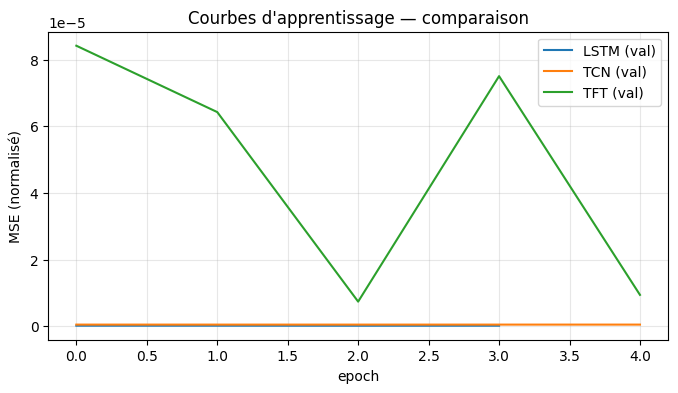

In [31]:
# Courbes d'apprentissage (validation) — tous les modèles
plt.figure(figsize=(8, 4))
for name in MODEL_NAMES:
    plt.plot(histories[name]["val_loss"], label=f"{name} (val)")
plt.xlabel("epoch"); plt.ylabel("MSE (normalisé)")
plt.title("Courbes d'apprentissage — comparaison"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 7bis. Comparaison des modèles
Tableau récapitulatif (RMSE / MAE / R² par cible, en unités physiques sur le jeu
de test) et comparaison visuelle du RMSE.

In [32]:
# ── Tableau comparatif ──
rows = []
for name in MODEL_NAMES:
    r = results[name]
    row = {"modèle": name, "params(M)": round(r["n_params"] / 1e6, 3)}
    for j, t in enumerate(TARGETS):
        row[f"RMSE_{t}"] = round(float(r["rmse"][:, j].mean()), 3)
        row[f"MAE_{t}"]  = round(float(r["mae"][:, j].mean()), 3)
        row[f"R2_{t}"]   = round(float(r["r2"][j]), 3)
    rows.append(row)
bench_df = pd.DataFrame(rows).set_index("modèle")
print(bench_df.to_string())
bench_df

        params(M)  RMSE_heat_index  MAE_heat_index  R2_heat_index
modèle                                                           
LSTM        0.335            0.049           0.036          0.615
TCN         0.103            0.082           0.061         -0.054
TFT         0.349            0.247           0.219        -12.521


,params(M),RMSE_heat_index,MAE_heat_index,R2_heat_index
modèle,,,,
LSTM,0.335,0.049,0.036,0.615
TCN,0.103,0.082,0.061,-0.054
TFT,0.349,0.247,0.219,-12.521


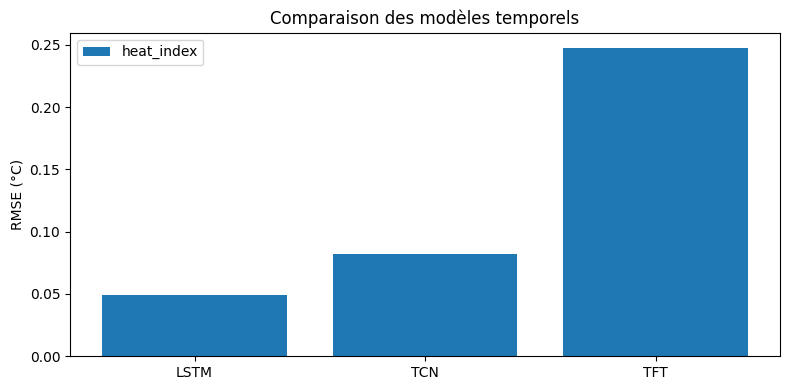

In [33]:
# ── Comparaison visuelle : RMSE moyen par modèle & cible ──
x = np.arange(len(MODEL_NAMES)); w = 0.8 / len(TARGETS)
fig, ax = plt.subplots(figsize=(8, 4))
for k, t in enumerate(TARGETS):
    vals = [results[n]["rmse"][:, k].mean() for n in MODEL_NAMES]
    ax.bar(x + (k - (len(TARGETS) - 1) / 2) * w, vals, w, label=t)
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("RMSE (°C)"); ax.set_title("Comparaison des modèles temporels")
ax.legend(); plt.tight_layout(); plt.show()

## 7ter. Métriques par horizon de prévision
RMSE et MAE en fonction de l'horizon `J+1 … J+OUTPUT_WINDOW`. L'erreur croît
normalement avec l'horizon : prévoir J+7 est plus dur que J+1.

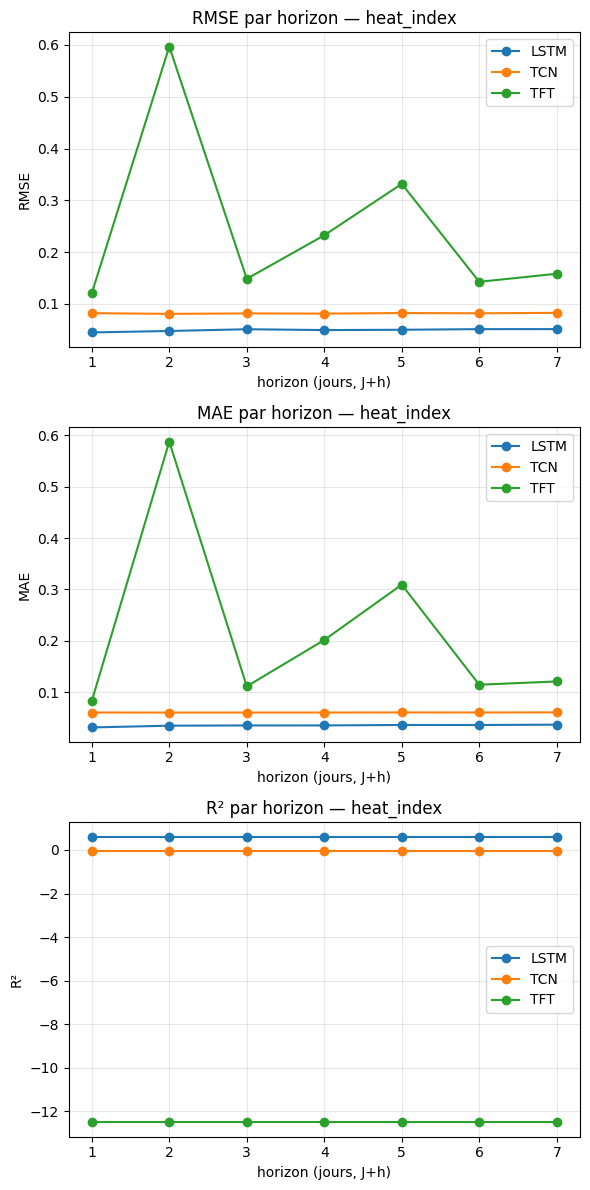

In [34]:
# ── RMSE & MAE par horizon (J+1 ... J+H), une courbe par modèle ──
H = OUTPUT_WINDOW
horizons = np.arange(1, H + 1)
panels = [("RMSE", "rmse"), ("MAE", "mae"), ("R²", "r2")]
fig, axes = plt.subplots(len(panels), len(TARGETS),
                         figsize=(6 * len(TARGETS), 4 * len(panels)), squeeze=False)
for r, (label, key) in enumerate(panels):
    for j, t in enumerate(TARGETS):
        ax = axes[r, j]
        for name in MODEL_NAMES:
            yv = results[name][key][:, j] if key != "r2" else np.full(H, results[name][key][j])
            ax.plot(horizons, yv, marker="o", label=name)
        ax.set_title(f"{label} par horizon — {t}")
        ax.set_xlabel("horizon (jours, J+h)"); ax.set_ylabel(f"{label}")
        ax.set_xticks(horizons); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

## 8. Prédictions vs réel (meilleur modèle)

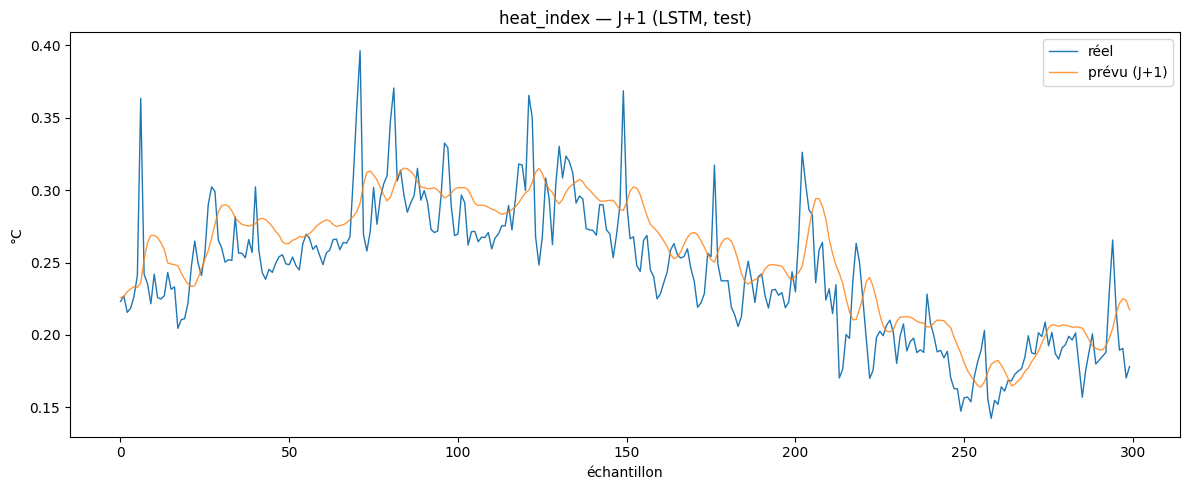

In [35]:
# Prévisions J+1 vs réel pour le meilleur modèle (début du jeu de test)
plt.figure(figsize=(12, 5))
for j, t in enumerate(TARGETS):
    plt.subplot(1, len(TARGETS), j + 1)
    n = min(300, pred.shape[0])
    plt.plot(true[:n, 0, j], label="réel", lw=1)
    plt.plot(pred[:n, 0, j], label="prévu (J+1)", lw=1, alpha=0.8)
    plt.title(f"{t} — J+1 ({best_name}, test)"); plt.legend()
    plt.xlabel("échantillon"); plt.ylabel("°C")
plt.tight_layout(); plt.show()

## 9. Save artifacts

In [36]:
# NB : tous les modèles ont déjà été sauvegardés dans ART_DIR/models/ pendant le benchmark,
# et les checkpoints de reprise sont dans ART_DIR/checkpoints/.
best = results[best_name]["model"]
best.save(str(ART_DIR / "lstm_gsod_heat_index.keras"))     # alias pratique du MEILLEUR modèle
joblib.dump(scaler_X, ART_DIR / "scaler_X.pkl")            # scalers Min-Max (fit train)
joblib.dump(scaler_y, ART_DIR / "scaler_y.pkl")
bench_df.to_csv(ART_DIR / "benchmark_metrics.csv")         # tableau comparatif

meta = {
    "framework": "tensorflow", "best_model": best_name,
    "models": {name: {"path": f"models/{name}.keras",
                      "rmse_mean": round(float(results[name]["rmse"].mean()), 3),
                      "params": int(results[name]["n_params"])}
               for name in MODEL_NAMES},
    "features": FEATURES, "targets": TARGETS,
    "scaler": "minmax", "feature_range": [0, 1],
    "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO,
              "scheme": "per-station chronological"},
    "input_window": INPUT_WINDOW, "output_window": OUTPUT_WINDOW,
    "hidden": HIDDEN, "n_layers": N_LAYERS,
    "dataset": "data/cleandata_gsod_by_station",
}
json.dump(meta, open(ART_DIR / "lstm_meta.json", "w"), indent=2)
print("Tous les modèles sauvegardés ->", MODELS_DIR, "(", ", ".join(MODEL_NAMES), ")")
print("meilleur alias:", ART_DIR / "lstm_gsod_heat_index.keras",
      "| scalers | benchmark_metrics.csv | lstm_meta.json")

Tous les modèles sauvegardés -> artifacts/models ( LSTM, TCN, TFT )
meilleur alias: artifacts/lstm_gsod_heat_index.keras | scalers | benchmark_metrics.csv | lstm_meta.json
